
# Método de Zhang no Problema de posicionamento do artigo Computer application for testing Kalman filter

Aluno: José Tayrone Santos de Oliveira

---

O objetivo é aplicar a lógica do caso linear no modelo linear local do problema de posicionamento

Esse código:

1. monta a geometria do problema
2. escolhe um trecho reto da trajetória e um ponto de operação $x^\star$
3. calcula o jacobiano $H^\star$
4. monta um modelo linear local
5. identifica o ganho fixo $W$ a partir da inovação
6. estima $R$ com os post-fit residuals
7. estima $S_a$, $Q$ e $P$ iterativamente
8. valida o modelo local com inovação, NIS e NEES

In [1]:

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy.optimize import minimize
from scipy.stats import chi2

plt.rcParams["figure.figsize"] = (10, 4)
plt.rcParams["axes.grid"] = True
np.set_printoptions(precision=4, suppress=True)

rng = np.random.default_rng(20260416)



## 1. Funções auxiliares

Usaremos:
- modelo PV em 2D
- quatro estações-base
- medição por distâncias
- jacobiano da medição


In [2]:

def build_pv_model(dt, S_a):
    F = np.array([
        [1.0, dt,  0.0, 0.0],
        [0.0, 1.0, 0.0, 0.0],
        [0.0, 0.0, 1.0, dt ],
        [0.0, 0.0, 0.0, 1.0],
    ])

    Q1 = S_a * np.array([
        [dt**3 / 3.0, dt**2 / 2.0],
        [dt**2 / 2.0, dt],
    ])

    Q = np.block([
        [Q1, np.zeros((2, 2))],
        [np.zeros((2, 2)), Q1],
    ])
    return F, Q

def h_ranges(x, stations, eps=1e-12):
    px, vx, py, vy = x
    dx = stations[:, 0] - px
    dy = stations[:, 1] - py
    d = np.sqrt(dx**2 + dy**2)
    return np.maximum(d, eps)

def H_jacobian_ranges(x, stations, eps=1e-12):
    px, vx, py, vy = x
    dx = stations[:, 0] - px
    dy = stations[:, 1] - py
    d = np.sqrt(dx**2 + dy**2)
    d = np.maximum(d, eps)

    H = np.zeros((len(stations), 4))
    H[:, 0] = -(dx / d)
    H[:, 2] = -(dy / d)
    return H

def square_trajectory(n_side=80, p_min=100.0, p_max=500.0, dt=1.0):
    pts = []

    for i in range(n_side):
        a = i / max(n_side - 1, 1)
        pts.append([p_min + a * (p_max - p_min), p_min])

    for i in range(1, n_side):
        a = i / max(n_side - 1, 1)
        pts.append([p_max, p_min + a * (p_max - p_min)])

    for i in range(1, n_side):
        a = i / max(n_side - 1, 1)
        pts.append([p_max - a * (p_max - p_min), p_max])

    for i in range(1, n_side - 1):
        a = i / max(n_side - 1, 1)
        pts.append([p_min, p_max - a * (p_max - p_min)])

    pos = np.array(pts)
    vel = np.zeros_like(pos)
    vel[1:] = (pos[1:] - pos[:-1]) / dt
    vel[0] = vel[1]
    return np.column_stack([pos[:, 0], vel[:, 0], pos[:, 1], vel[:, 1]])



## 2. Trecho local e ponto de operação

Escolhemos um trecho reto da trajetória, distante dos cantos, para fazer a linearização local

In [3]:

dt = 1.0
stations = np.array([
    [0.0,   0.0],
    [0.0, 600.0],
    [600.0, 600.0],
    [600.0,   0.0],
])

x_nominal = square_trajectory(n_side=80, p_min=100.0, p_max=500.0, dt=dt)

k0, k1 = 20, 60
x_window = x_nominal[k0:k1]
x_star = np.mean(x_window, axis=0)
H_star = H_jacobian_ranges(x_star, stations)
h_star = h_ranges(x_star, stations)

print("Janela escolhida:", (k0, k1))
print("x_star =")
print(x_star)
print("\nH_star =")
print(H_star)


Janela escolhida: (20, 60)
x_star =
[300.       5.0633 100.       0.    ]

H_star =
[[ 0.9487  0.      0.3162  0.    ]
 [ 0.5145  0.     -0.8575  0.    ]
 [-0.5145  0.     -0.8575  0.    ]
 [-0.9487  0.      0.3162  0.    ]]


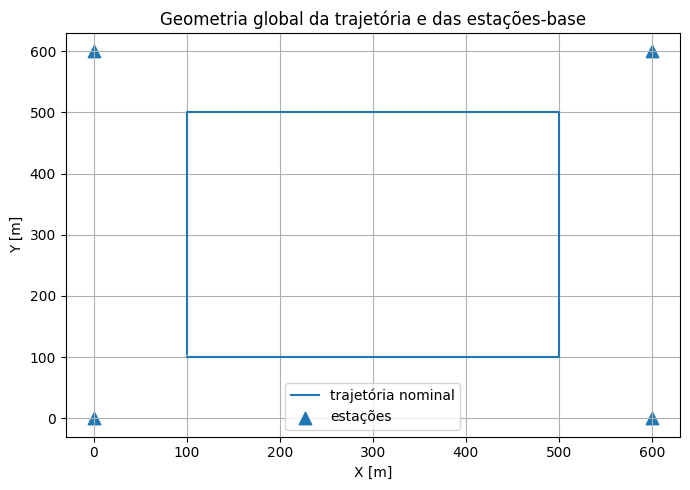

In [4]:

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(x_nominal[:, 0], x_nominal[:, 2], label="trajetória nominal")
ax.scatter(stations[:, 0], stations[:, 1], marker="^", s=80, label="estações")
ax.set_title("Geometria global da trajetória e das estações-base")
ax.set_xlabel("X [m]")
ax.set_ylabel("Y [m]")
ax.legend()
plt.tight_layout()
plt.show()


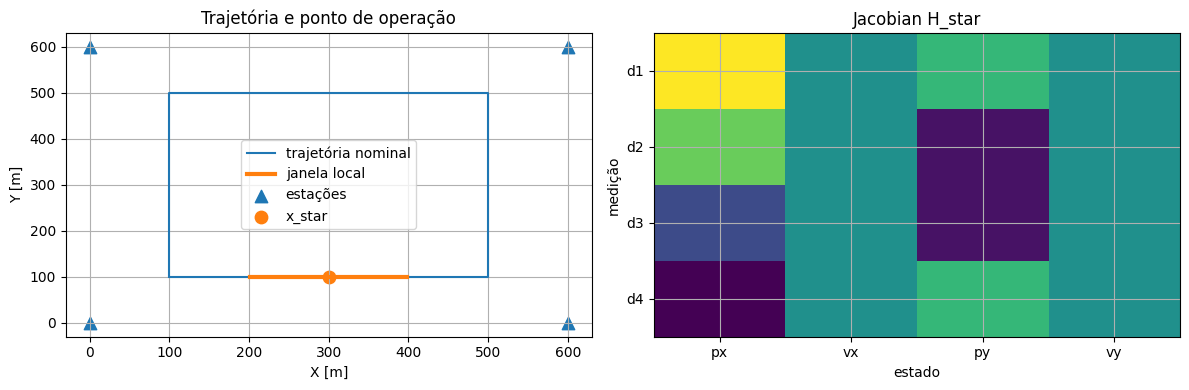

In [5]:

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(x_nominal[:, 0], x_nominal[:, 2], label="trajetória nominal")
ax[0].plot(x_window[:, 0], x_window[:, 2], linewidth=3, label="janela local")
ax[0].scatter(stations[:, 0], stations[:, 1], marker="^", s=80, label="estações")
ax[0].scatter([x_star[0]], [x_star[2]], marker="o", s=80, label="x_star")
ax[0].set_title("Trajetória e ponto de operação")
ax[0].set_xlabel("X [m]")
ax[0].set_ylabel("Y [m]")
ax[0].legend()

ax[1].imshow(H_star, aspect="auto")
ax[1].set_title("Jacobian H_star")
ax[1].set_xlabel("estado")
ax[1].set_ylabel("medição")
ax[1].set_xticks(range(4), ["px", "vx", "py", "vy"])
ax[1].set_yticks(range(4), [f"d{i+1}" for i in range(4)])
plt.tight_layout()
plt.show()



## 3. Modelo linear local

Perto de $x^\star$, a medição é aproximada por
$$
h(x) \approx h(x^\star) + H^\star(x-x^\star).
$$

Definindo
$$
\delta x_k = x_k - x^\star,\qquad
\delta z_k = z_k - h(x^\star),
$$
obtemos
$$
\delta x_{k+1} = F\delta x_k + w_k,\qquad
\delta z_k \approx H^\star \delta x_k + v_k.
$$

Agora o problema volta a ter a forma linear


## 4. Modelo linear local

Nessa validação local, usamos um sistema linear estocástico coerente com o ponto de operação

Valores verdadeiros usados:

- $\sigma_{\text{local,true}} = 1.0$
- $S_{a,\text{local,true}} = 0.1$


In [6]:

sigma_local_true = 1.0
Sa_local_true = 0.1

F_local, Q_local_true = build_pv_model(dt, Sa_local_true)
Q_base = build_pv_model(dt, 1.0)[1]
R_local_true = (sigma_local_true**2) * np.eye(4)

def simulate_local_linear_system(F, H, Q, R, N, rng):
    n = F.shape[0]
    m = H.shape[0]
    x = np.zeros((N + 1, n))
    z = np.zeros((N, m))
    for k in range(N):
        wk = rng.multivariate_normal(np.zeros(n), Q)
        vk = rng.multivariate_normal(np.zeros(m), R)
        x[k + 1] = F @ x[k] + wk
        z[k] = H @ x[k + 1] + vk
    return x, z

N_local = 6000
dx_true, dz = simulate_local_linear_system(F_local, H_star, Q_local_true, R_local_true, N_local, rng)

print("N_local =", N_local)
print("Q_local_true =\n", Q_local_true)
print("\nR_local_true =\n", R_local_true)


N_local = 6000
Q_local_true =
 [[0.0333 0.05   0.     0.    ]
 [0.05   0.1    0.     0.    ]
 [0.     0.     0.0333 0.05  ]
 [0.     0.     0.05   0.1   ]]

R_local_true =
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]



## 5. Filtro de ganho fixo, inovação e post-fit residual

Repetimos a lógica do caso 1:
- escolhemos um ganho inicial subótimo $W_0$
- rodamos um filtro estacionário com ganho fixo
- coletamos inovação e post-fit residual
- calculamos autocovariâncias da inovação


In [7]:

def run_fixed_gain_filter(F, H, W, z, x0=None):
    n = F.shape[0]
    N = len(z)

    x_upd = np.zeros(n) if x0 is None else np.array(x0, dtype=float).copy()
    x_pred_hist = np.zeros((N, n))
    x_upd_hist = np.zeros((N, n))
    innov = np.zeros((N, H.shape[0]))
    postfit = np.zeros((N, H.shape[0]))

    for k in range(N):
        x_pred = F @ x_upd
        nu = z[k] - H @ x_pred
        x_upd = x_pred + W @ nu
        mu = z[k] - H @ x_upd

        x_pred_hist[k] = x_pred
        x_upd_hist[k] = x_upd
        innov[k] = nu
        postfit[k] = mu

    return x_pred_hist, x_upd_hist, innov, postfit

def innovation_covariances_matrix(innov, M):
    innov = np.asarray(innov, dtype=float)
    C = []
    for lag in range(M):
        if lag == 0:
            Ck = innov.T @ innov / len(innov)
        else:
            Ck = innov[lag:].T @ innov[:-lag] / (len(innov) - lag)
        C.append(Ck)
    return C

def objective_J_matrix(C):
    C0 = 0.5 * (C[0] + C[0].T)
    L = np.linalg.cholesky(C0 + 1e-10 * np.eye(C0.shape[0]))
    Linv = np.linalg.inv(L)
    J = 0.0
    for k in range(1, len(C)):
        Nk = Linv @ C[k] @ Linv.T
        J += np.linalg.norm(Nk, ord="fro")**2
    return 0.5 * J

def spectral_radius(A):
    return np.max(np.abs(np.linalg.eigvals(A)))

def J_for_W_flat(W_flat, F, H, z, M=15, burn_in=300):
    n, m = F.shape[0], H.shape[0]
    W = W_flat.reshape(n, m)
    Fbar = F @ (np.eye(n) - W @ H)
    if spectral_radius(Fbar) >= 0.999:
        return 1e6
    _, _, innov, _ = run_fixed_gain_filter(F, H, W, z)
    C = innovation_covariances_matrix(innov[burn_in:], M)
    return objective_J_matrix(C)

sigma_guess = 2.0
Sa_guess = 1e-3
F_guess, Q_guess = build_pv_model(dt, Sa_guess)
R_guess = (sigma_guess**2) * np.eye(4)
Pbar_guess = la.solve_discrete_are(F_guess.T, H_star.T, Q_guess, R_guess)
S_guess = H_star @ Pbar_guess @ H_star.T + R_guess
W0 = Pbar_guess @ H_star.T @ np.linalg.inv(S_guess)

J0 = J_for_W_flat(W0.ravel(), F_local, H_star, dz)
print("J(W0) =", J0)


J(W0) = 5.941590187805307


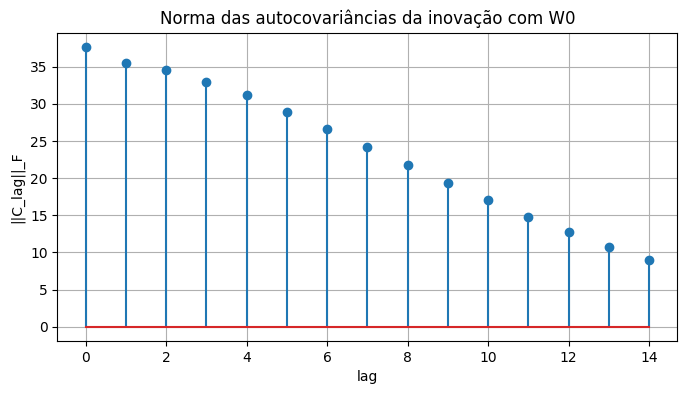

In [8]:

C0_init = innovation_covariances_matrix(run_fixed_gain_filter(F_local, H_star, W0, dz)[2][300:], 15)

plt.figure(figsize=(8, 4))
vals = [np.linalg.norm(Ck, ord="fro") for Ck in C0_init]
plt.stem(range(len(vals)), vals)
plt.title("Norma das autocovariâncias da inovação com W0")
plt.xlabel("lag")
plt.ylabel("||C_lag||_F")
plt.show()



## 6. Identificação local de $W$

Nessa etapa, aplicamos a parte central da lógica de Zhang:
- o ganho é ajustado para tornar a inovação o mais branca possível
- minimiza-se a função objetivo construída com as autocovariâncias da inovação


In [9]:

res_opt = minimize(
    fun=lambda w: J_for_W_flat(w, F_local, H_star, dz, M=15, burn_in=300),
    x0=W0.ravel(),
    method="L-BFGS-B",
    options={"maxiter": 50},
)

W_est = res_opt.x.reshape(F_local.shape[0], H_star.shape[0])
J_est = res_opt.fun

Pbar_true_local = la.solve_discrete_are(F_local.T, H_star.T, Q_local_true, R_local_true)
S_true_local = H_star @ Pbar_true_local @ H_star.T + R_local_true
W_true_local = Pbar_true_local @ H_star.T @ np.linalg.inv(S_true_local)

print("Sucesso da otimização:", res_opt.success)
print("Mensagem:", res_opt.message)
print("\nJ inicial =", J0)
print("J final    =", J_est)
print("\n||W_est - W_true_local||_F =", np.linalg.norm(W_est - W_true_local, ord='fro'))


Sucesso da otimização: True
Mensagem: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH

J inicial = 5.941590187805307
J final    = 0.015896808578017705

||W_est - W_true_local||_F = 0.0400158959926878


In [10]:

summary_W = pd.DataFrame({
    "elemento": [f"W[{i},{j}]" for i in range(W_est.shape[0]) for j in range(W_est.shape[1])],
    "estimado": W_est.ravel(),
    "referência teórica local": W_true_local.ravel(),
})
summary_W["erro absoluto"] = np.abs(summary_W["estimado"] - summary_W["referência teórica local"])
summary_W.head(12)


,elemento,estimado,referência teórica local,erro absoluto
0,"W[0,0]",0.256317,0.254779,0.001538
1,"W[0,1]",0.129470,0.138173,0.008703
2,"W[0,2]",-0.115239,-0.138173,0.022934
3,"W[0,3]",-0.246008,-0.254779,0.008771
4,"W[1,0]",0.125981,0.120274,0.005707
5,"W[1,1]",0.061783,0.065228,0.003445
6,"W[1,2]",-0.071977,-0.065228,0.006749
7,"W[1,3]",-0.105601,-0.120274,0.014673
8,"W[2,0]",0.115377,0.112644,0.002733
9,"W[2,1]",-0.285396,-0.305450,0.020053



## 7. Estimação de $R$ local via post-fit residuals

Repetimos a lógica do caso 1, mas no caso matricial

Com:
- $S = E[\nu_k \nu_k^\top]$: covariância da inovação
- $G = E[\mu_k \mu_k^\top]$: covariância do post-fit residual

Usaremos a forma matricial análoga ao método baseado em $G = R S^{-1} R$, obtendo $R$ por raiz quadrada matricial


In [11]:

def symmetrize(A):
    return 0.5 * (A + A.T)

def matrix_sqrt_psd(A):
    vals, vecs = np.linalg.eigh(symmetrize(A))
    vals = np.clip(vals, 0.0, None)
    return vecs @ np.diag(np.sqrt(vals)) @ vecs.T

def matrix_invsqrt_psd(A):
    vals, vecs = np.linalg.eigh(symmetrize(A))
    vals = np.clip(vals, 1e-12, None)
    return vecs @ np.diag(1.0 / np.sqrt(vals)) @ vecs.T

def estimate_R_from_innov_postfit(innov, postfit, burn_in=500):
    nu = innov[burn_in:]
    mu = postfit[burn_in:]

    S = symmetrize(nu.T @ nu / len(nu))
    G = symmetrize(mu.T @ mu / len(mu))

    S_half = matrix_sqrt_psd(S)
    S_invhalf = matrix_invsqrt_psd(S)
    middle = S_invhalf @ G @ S_invhalf
    R_est = S_half @ matrix_sqrt_psd(middle) @ S_half
    return symmetrize(S), symmetrize(G), symmetrize(R_est)

_, x_upd_est, innov_est, postfit_est = run_fixed_gain_filter(F_local, H_star, W_est, dz)
S_est, G_est, R_est = estimate_R_from_innov_postfit(innov_est, postfit_est, burn_in=500)

print("S_est =\n", S_est)
print("\nR_est =\n", R_est)
print("\nR_local_true =\n", R_local_true)
print("\n||R_est - R_true||_F =", np.linalg.norm(R_est - R_local_true, ord='fro'))


S_est =
 [[ 1.7389  0.1136 -0.5916 -0.5514]
 [ 0.1136  1.8219  0.4759 -0.5686]
 [-0.5916  0.4759  1.8511  0.1549]
 [-0.5514 -0.5686  0.1549  1.7727]]

R_est =
 [[ 1.0168  0.0139 -0.0186 -0.0029]
 [ 0.0139  1.0296  0.0172 -0.0069]
 [-0.0186  0.0172  1.0253  0.0552]
 [-0.0029 -0.0069  0.0552  1.0527]]

R_local_true =
 [[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 0. 1. 0.]
 [0. 0. 0. 1.]]

||R_est - R_true||_F = 0.11161798568873771



## 8. Estimação iterativa de $S_a$, $Q$ e $P$

No caso local, a matriz de processo tem estrutura conhecida:
$$
Q = S_a\,Q_{\text{base}}
$$

Então seguimos uma lógica análoga ao caso 1:
- fixamos a estrutura de $Q$
- iteramos uma equação fixa para $P$
- projetamos a matriz resultante sobre $Q_{\text{base}}$ para atualizar $S_a$


In [12]:

def initial_Sa_from_WSW(W, S, Q_base):
    D0 = symmetrize(W @ S @ W.T)
    num = np.sum(D0 * Q_base)
    den = np.sum(Q_base * Q_base)
    return max(float(num / den), 1e-9)

def estimate_Sa_Q_P_iterative(F, H, W, S, R, Q_base, max_outer=100, max_inner=500, tol=1e-12):
    n = F.shape[0]
    Sa = initial_Sa_from_WSW(W, S, Q_base)
    P = np.eye(n)
    Sa_hist = [Sa]

    Rinv = np.linalg.inv(R)

    for _ in range(max_outer):
        Q = Sa * Q_base
        P_inner = P.copy()

        for _ in range(max_inner):
            M = F @ P_inner @ F.T + Q
            P_next = np.linalg.inv(np.linalg.inv(M) + H.T @ Rinv @ H)
            P_next = symmetrize(P_next)
            if np.linalg.norm(P_next - P_inner) < tol:
                P_inner = P_next
                break
            P_inner = P_next

        P = P_inner

        D = symmetrize(P + W @ S @ W.T - F @ P @ F.T)
        num = np.sum(D * Q_base)
        den = np.sum(Q_base * Q_base)
        Sa_new = max(float(num / den), 1e-9)

        Sa_hist.append(Sa_new)
        if abs(Sa_new - Sa) < 1e-10:
            Sa = Sa_new
            break
        Sa = Sa_new

    Q_est = Sa * Q_base
    return Sa, Q_est, P, Sa_hist

Sa_est_local, Q_est_local, P_est_local, Sa_hist = estimate_Sa_Q_P_iterative(
    F=F_local,
    H=H_star,
    W=W_est,
    S=S_est,
    R=R_est,
    Q_base=Q_base,
)

print("Sa inicial =", Sa_hist[0])
print("Sa final   =", Sa_est_local)
print("Sa verdadeiro =", Sa_local_true)
print("\nQ_est_local =\n", Q_est_local)
print("\nQ_local_true =\n", Q_local_true)
print("\n||Q_est - Q_true||_F =", np.linalg.norm(Q_est_local - Q_local_true, ord='fro'))
print("\nP_est_local =\n", P_est_local)


Sa inicial = 0.28568998821709807
Sa final   = 0.2856798760655312
Sa verdadeiro = 0.1

Q_est_local =
 [[0.0952 0.1428 0.     0.    ]
 [0.1428 0.2857 0.     0.    ]
 [0.     0.     0.0952 0.1428]
 [0.     0.     0.1428 0.2857]]

Q_local_true =
 [[0.0333 0.05   0.     0.    ]
 [0.05   0.1    0.     0.    ]
 [0.     0.     0.0333 0.05  ]
 [0.     0.     0.05   0.1   ]]

||Q_est - Q_true||_F = 0.3333055779937316

P_est_local =
 [[0.0046 0.     0.0001 0.    ]
 [0.     0.     0.     0.    ]
 [0.0001 0.     0.0059 0.    ]
 [0.     0.     0.     0.    ]]


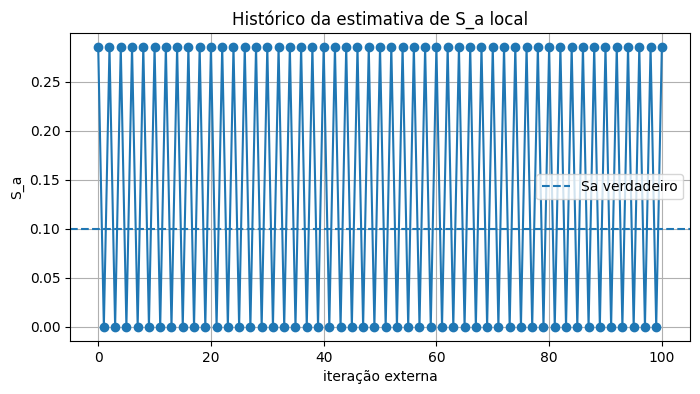

In [13]:

plt.figure(figsize=(8, 4))
plt.plot(Sa_hist, marker="o")
plt.axhline(Sa_local_true, linestyle="--", label="Sa verdadeiro")
plt.title("Histórico da estimativa de S_a local")
plt.xlabel("iteração externa")
plt.ylabel("S_a")
plt.legend()
plt.show()



## 9. Diagnósticos locais: inovação, NIS e NEES

A validação é feita dentro do modelo linear local

Aqui vamos responder a pergunta “A sintonia do modelo local ficou coerente?”


In [14]:

def whitened_innovation_matrix(innov, S):
    S_invhalf = matrix_invsqrt_psd(S)
    return (S_invhalf @ innov.T).T

def autocorrelation_lags_vector(e, max_lag):
    e = np.asarray(e, dtype=float)
    e0 = e - np.mean(e, axis=0, keepdims=True)
    C0 = symmetrize(e0.T @ e0 / len(e0))
    C0_invhalf = matrix_invsqrt_psd(C0)

    vals = [1.0]
    for lag in range(1, max_lag + 1):
        Ck = e0[lag:].T @ e0[:-lag] / (len(e0) - lag)
        Nk = C0_invhalf @ Ck @ C0_invhalf
        vals.append(float(np.linalg.norm(Nk, ord="fro")))
    return np.array(vals)

def compute_nees_sequence(x_true, x_upd_hist, P):
    P_inv = np.linalg.inv(P)
    ex = x_true[1:] - x_upd_hist
    nees = np.einsum("bi,ij,bj->b", ex, P_inv, ex)
    return ex, nees

burn_in = 500

e_local = whitened_innovation_matrix(innov_est[burn_in:], S_est)
nis_local = np.einsum("bi,ij,bj->b", innov_est[burn_in:], np.linalg.inv(S_est), innov_est[burn_in:])
ex_local, nees_local = compute_nees_sequence(dx_true, x_upd_est, P_est_local)
nees_local = nees_local[burn_in:]
ex_local = ex_local[burn_in:]

print("Média da inovação branca =", np.mean(e_local, axis=0))
print("Variância média por componente =", np.var(e_local, axis=0))
print("Média do NIS local =", np.mean(nis_local))
print("Valor esperado do NIS local =", H_star.shape[0])
print("Média da NEES local =", np.mean(nees_local))
print("Valor esperado da NEES local =", F_local.shape[0])


Média da inovação branca = [0.0155 0.0069 0.0043 0.0009]
Variância média por componente = [0.9998 1.     1.     1.    ]
Média do NIS local = 4.0
Valor esperado do NIS local = 4
Média da NEES local = 2995979.522091183
Valor esperado da NEES local = 4


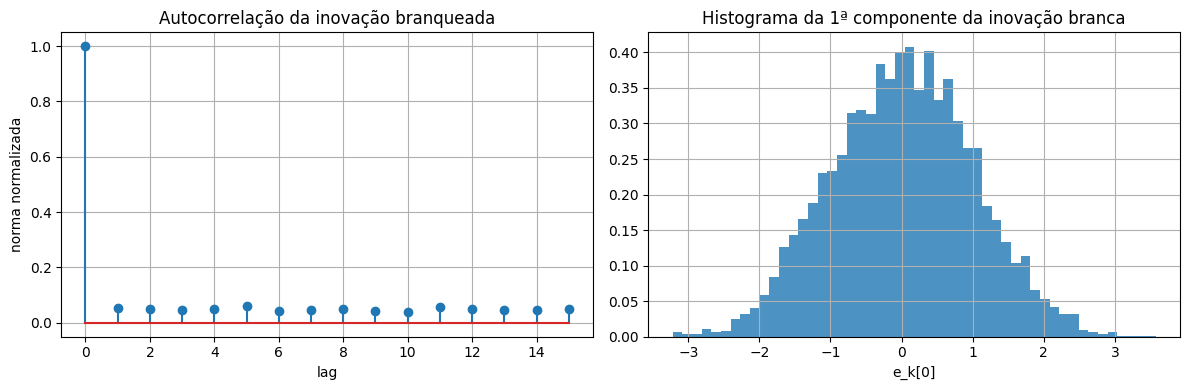

In [15]:

max_lag = 15
ac_vals = autocorrelation_lags_vector(e_local, max_lag)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].stem(range(max_lag + 1), ac_vals)
ax[0].set_title("Autocorrelação da inovação branqueada")
ax[0].set_xlabel("lag")
ax[0].set_ylabel("norma normalizada")

ax[1].hist(e_local[:, 0], bins=50, density=True, alpha=0.8)
ax[1].set_title("Histograma da 1ª componente da inovação branca")
ax[1].set_xlabel("e_k[0]")

plt.tight_layout()
plt.show()


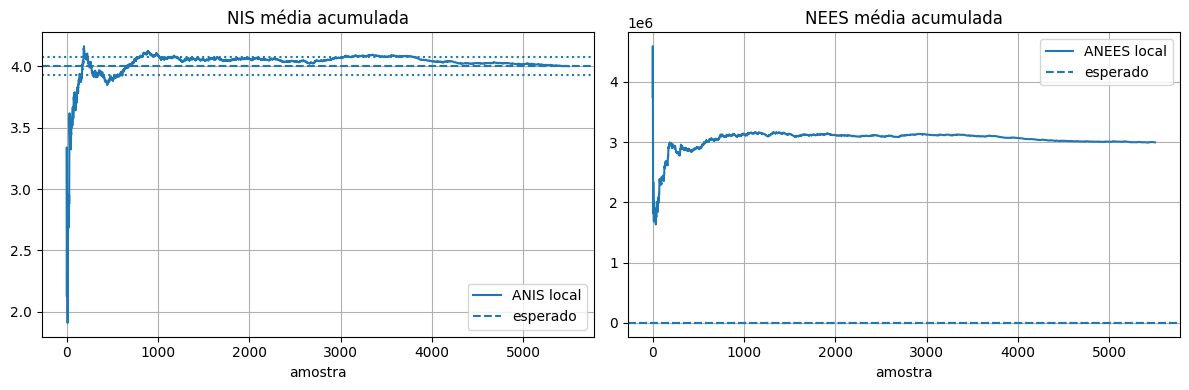

In [16]:

alpha = 0.05
m_meas = H_star.shape[0]
n_state = F_local.shape[0]

running_avg_nis = np.cumsum(nis_local) / np.arange(1, len(nis_local) + 1)
running_avg_nees = np.cumsum(nees_local) / np.arange(1, len(nees_local) + 1)

lower_nis = chi2.ppf(alpha / 2, df=len(nis_local) * m_meas) / len(nis_local)
upper_nis = chi2.ppf(1 - alpha / 2, df=len(nis_local) * m_meas) / len(nis_local)

lower_nees = chi2.ppf(alpha / 2, df=len(nees_local) * n_state) / len(nees_local)
upper_nees = chi2.ppf(1 - alpha / 2, df=len(nees_local) * n_state) / len(nees_local)

fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(running_avg_nis, label="ANIS local")
ax[0].axhline(m_meas, linestyle="--", label="esperado")
ax[0].axhline(lower_nis, linestyle=":")
ax[0].axhline(upper_nis, linestyle=":")
ax[0].set_title("NIS média acumulada")
ax[0].set_xlabel("amostra")
ax[0].legend()

ax[1].plot(running_avg_nees, label="ANEES local")
ax[1].axhline(n_state, linestyle="--", label="esperado")
ax[1].axhline(lower_nees, linestyle=":")
ax[1].axhline(upper_nees, linestyle=":")
ax[1].set_title("NEES média acumulada")
ax[1].set_xlabel("amostra")
ax[1].legend()

plt.tight_layout()
plt.show()


In [17]:

summary_local = pd.DataFrame({
    "parâmetro": [
        "J inicial",
        "J final",
        "||W_est - W_true_local||_F",
        "||R_est - R_true||_F",
        "Sa_est_local",
        "Sa_true_local",
        "||Q_est - Q_true||_F",
        "média NIS local",
        "valor esperado NIS",
        "média NEES local",
        "valor esperado NEES",
    ],
    "valor": [
        float(J0),
        float(J_est),
        float(np.linalg.norm(W_est - W_true_local, ord='fro')),
        float(np.linalg.norm(R_est - R_local_true, ord='fro')),
        float(Sa_est_local),
        float(Sa_local_true),
        float(np.linalg.norm(Q_est_local - Q_local_true, ord='fro')),
        float(np.mean(nis_local)),
        float(m_meas),
        float(np.mean(nees_local)),
        float(n_state),
    ]
})
summary_local


,parâmetro,valor
0,J inicial,5.941590e+00
1,J final,1.589681e-02
2,||W_est - W_true_local||_F,4.001590e-02
3,||R_est - R_true||_F,1.116180e-01
4,Sa_est_local,2.856799e-01
5,Sa_true_local,1.000000e-01
6,||Q_est - Q_true||_F,3.333056e-01
7,média NIS local,4.000000e+00
8,valor esperado NIS,4.000000e+00
9,média NEES local,2.995980e+06
